# Analysis of Ship Wreck Data from the Roman Empire
## Gene Foxwell
## Dataset: https://oxrep.classics.ox.ac.uk/databases/shipwrecks_database/

Strauss, J. (2013). Shipwrecks Database. Version 1.0. Accessed (date): oxrep.classics.ox.ac.uk/databases/shipwrecks_database/

We will use this dataset to try and determine the most dangerous sailing routes in the Roman Empire. We will take into account the ships origin and destination, the tonnage of the vessel, as well as the sea area. Finally we look at the estimated positions of the wrecks to see if there were specific "danger" zones that put ships in danger more than others.

## Dataset Overview

We will use this dataset to search for patterns in Roman Shipwrecks. We are interested in where they happened, and the characteristics of the ships that they happened to. To this end, we are interested in the following fields:

* **Wreck ID**: Allows us to reference the ship wreck.
* **Sea area**: Tells us what area of the sea the wreck happened in.
* **Lattitude & Longitude**: Rough estimates of the wrecks location. (This were kept impercise in the dataset to discourage looting)
* **Estimated tonnage**: Roughly how large this ship was.
* **Place of origin**: Where the ship was coming from.
* **Place of destination**: Where the ship was going.

## Load and Clean the Dataset

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [172]:
df = pd.read_csv("data/StraussShipwrecks.csv")
df.head()

,Wreck ID,Strauss ID,Name,Parker Number,Sea area,Country,Region,Latitude,Longitude,Min depth,...,Columns etc,Sarcophagi,Blocks,Marble type,Other cargo,Hull remains,Shipboard paraphernalia,Ship equipment,Estimated tonnage,Amphora type
0,1,331,Komiza,NaN,Adriatic,Croatia,Vis Island,43.03333,16.08333,30.0,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,328,Lokunji,NaN,Adriatic,Croatia,Kvarner region,44.70000,14.28333,4.0,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,329,Maharac Cape,NaN,Adriatic,Croatia,Mljet island,42.73333,17.66666,3.0,...,False,False,False,NaN,Eastern coarse ware pottery of biconical dishe...,NaN,NaN,NaN,NaN,NaN
3,4,330,Mlin,702,Adriatic,Croatia,Split channel,43.45000,16.23333,25.0,...,False,False,False,NaN,NaN,Remains of the hull.,NaN,"Two lead anchor stocks, though possibly not fr...",NaN,NaN
4,5,322,Plavac B,832,Adriatic,Croatia,"Zlarin Island, central Dalmatia",NaN,NaN,NaN,...,False,False,False,NaN,NaN,NaN,NaN,.,NaN,NaN


Ok, we have the data. We don't need all those fields. We'll clean this table up a bit so it only has the columns we actually want.

In [173]:
def prepare_shipwreck_data(df_source):
    """
    Drops columns that we won't be using from the dataframe.

    Args:
        df_source: the source dataframe.
    Returns:
        A new dataframe with only the expected columns.
    """    
    df_results = df_source.copy()

    df_results = df_results.drop(columns=["Strauss ID", 
                                          "Country",
                                          "Region",
                                          "Parker Number", 
                                          "Depth", 
                                          "Period", 
                                          "Dating", 
                                          "Earliest date",
                                          "Latest date",
                                          "Date range",
                                          "Mid point of date range", 
                                          "Probability", 
                                          "Reference", 
                                          "Comments", 
                                          "Amphorae", 
                                          "Marble",
                                          "Columns etc",
                                          "Sarcophagi",
                                          "Blocks",
                                          "Marble type",
                                          "Other cargo",
                                          "Hull remains",
                                          "Shipboard paraphernalia",
                                          "Ship equipment",
                                          "Min depth",
                                          "Max depth",
                                          "Amphora type"
                                        ])

    return df_results

In [174]:
df_shipwrecks = prepare_shipwreck_data(df)
df_shipwrecks.head()

,Wreck ID,Name,Sea area,Latitude,Longitude,Place of origin,Place of destination,Estimated tonnage
0,1,Komiza,Adriatic,43.03333,16.08333,Egypt,Northern Italy,NaN
1,2,Lokunji,Adriatic,44.70000,14.28333,Cos,Northern Italy,NaN
2,3,Maharac Cape,Adriatic,42.73333,17.66666,Rhodes,Northern Italy,NaN
3,4,Mlin,Adriatic,43.45000,16.23333,Aegean,Northern Italy,NaN
4,5,Plavac B,Adriatic,NaN,NaN,NaN,NaN,NaN


We can already see some missing values here. We'll handle these on a case by case basis when we analyze the different aspects of the problem. 

Here are the factors we want to investigate regarding Ship Wrecks:

* Frequency of Ship Wrecks by Trade Route. A Trade Route is a "Place of Origin" "Place of Destination" pair.
* Frequency of Ship Wrecks by Sea Area.
* Frequency of Ship Wrecks by Tonnage.
* How does the frequency of Ship Wrecks by Sea Area and Trade Route relate to a Ships tonnage?
* Do any clusters exist in the Lat / Long - areas that are especially dangerous to sail by?

Let's get started.

## **RQ1**: What is the frequency of Ship Wrecks by Trade Route?

First we have to group the ship wrecks into trade routes. To do this, we'll create a new field "Trade Route". Trade Route will be a string that Origination-Destination. We will remove any rows that do not have a recorded point of origin or destination before doing this analysis.

In [175]:
def create_trade_route_df(df_source):
    """
    Creates a new dataframe that includes a "traderoutes" column. traderoutes is a concatenation of Place of origin and Place of destination. Rows which are missing either a
    Place of origin or a Place of destination are removed before this column is created.

    Args:
        df_source: The source data frame.

    Returns:
        A copy of the source dataframe modified to include the "traderoutes" column as described above.
    """
    df_results = df_source.copy()
    df_results = df_results.drop(columns=["Sea area", "Latitude", "Longitude", "Estimated tonnage"])


    # some traderoutes have partial information denoted by ?, we will drop these from the analysis
    df_results["Place of origin"] = df_results["Place of origin"].replace("?", np.nan, regex=False)
    df_results["Place of destination"] = df_results["Place of destination"].replace("?", np.nan, regex=False)
    
    df_results.dropna(inplace=True)

    df_results["traderoutes"] = df_results["Place of origin"] + "-" + df_results["Place of destination"]

    # ? and (?) tokens have been used to indicate the original researcher was unsure of the destination or origin.
    # for this analysis, we will assume their instincts where right and strip the ? and (?) from the descriptions.
    df_results["traderoutes"] = df_results["traderoutes"].str.replace("?", "", regex=False)
    df_results["traderoutes"] = df_results["traderoutes"].str.replace("()", "", regex=False)

    return df_results

In [176]:
df_traderoutes = create_trade_route_df(df_source=df_shipwrecks)
df_traderoutes.head()

,Wreck ID,Name,Place of origin,Place of destination,traderoutes
0,1,Komiza,Egypt,Northern Italy,Egypt-Northern Italy
1,2,Lokunji,Cos,Northern Italy,Cos-Northern Italy
2,3,Maharac Cape,Rhodes,Northern Italy,Rhodes-Northern Italy
3,4,Mlin,Aegean,Northern Italy,Aegean-Northern Italy
5,6,Tramerka,Rhodes,northern Italy,Rhodes-northern Italy


Now, lets see how many unique traderoutes we can identify from the data. This will inform our approach to charting it.

In [177]:
df_traderoutes["traderoutes"].unique()

array(['Egypt-Northern Italy', 'Cos-Northern Italy',
       'Rhodes-Northern Italy', 'Aegean-Northern Italy',
       'Rhodes-northern Italy', 'Aegean via Cosa-France', 'Aegean.-Rome',
       'Aegean/N. Africa/Propontis-Sicily/Rome',
       'Proconnesus-Claros, Turkey', 'Greece-Northern Italy',
       'Eastern Cilicia-Aegean Rome', 'Cos-Black Sea',
       'Thessaly, Proconnesus-Black Sea', 'Corinth-Italy', 'Aegean-Italy',
       'Corinth-Pergamum', 'Adriatic-Aegean', 'Carystos-Italy',
       'Aegean-Levant', 'Italy-Caesarea', 'Adriatic-Alexandria',
       'Italy via Crete and Rhodes-Alexandria', 'Aegean-North Africa',
       'Thasos-Black Sea', 'Aegean-India', 'Alex/ Pergamum/ Aegean-Rome',
       'Rhodes-Rome', 'Assos-Italy', 'Aegean-Rome', 'Italy-India',
       'Aegean-France/Spain', 'Luna-South of France', 'Cos-Rome',
       'Aegean, Italy-France/Spain', 'Cos, Crete, Italy-France',
       'Luna-Inland France', 'Aegean via southern Italy-France',
       'Egypt Luna-France, Spain', 'Ae

There's a lot of traderoutes here. Let's take a peak at how frequent they are - perhaps we can filter out rare traderoutes and help make this a little more comprehensible when we visualize it.

In [178]:
df_traderoutes["traderoutes"].value_counts()

traderoutes
Aegean-Italy                                           8
Aegean-Rome                                            8
Aegean-Northern Italy                                  6
Luna-Rome                                              3
Luna-South west France Inland France                   3
                                                      ..
Herakleia Pontica-Bizone                               1
Lusitania-Rome                                         1
Southern Spain via Marseilles-Pisa                     1
Southern Levant or Cyprus-Southern Levant or Cyprus    1
central western Italy-Aegean                           1
Name: count, Length: 129, dtype: int64

In [179]:
df_traderoutes["traderoutes"].value_counts().describe()

count    129.000000
mean       1.294574
std        1.026242
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
Name: count, dtype: float64

The vast majority of traderoutes are only recorded once. Given the times, it doesn't seem unreasonable that any frequented traderoute could have at least one shipwreck - storms, navigator error, and other emergencies can't be ruled out even with today's technology. There do seem to be a few traderoutes that have more frequent ship wrecks than others. To try and capture those, let's grab the top 10% of the data and visualize it using a bar chart.

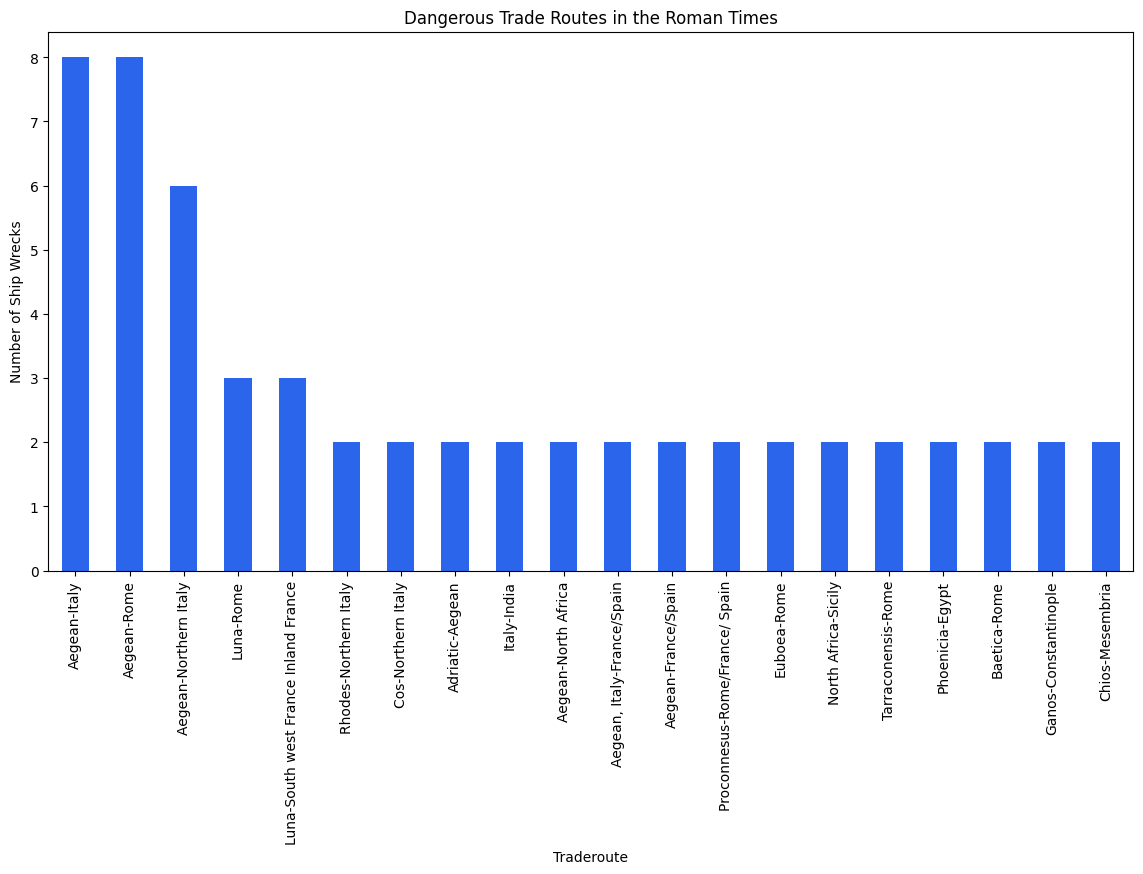

In [180]:
traderoute_counts = df_traderoutes["traderoutes"].value_counts()
q90 = traderoute_counts.quantile(0.90)

keep_classes = traderoute_counts[traderoute_counts >= q90].index
q90_classes = df_traderoutes[df_traderoutes["traderoutes"].isin(keep_classes)]

plt.figure(figsize=(14, 7))
q90_classes["traderoutes"].value_counts().plot(kind="bar", color="#2B65EC")
plt.title("Dangerous Trade Routes in the Roman Times")
plt.xlabel("Traderoute")
plt.ylabel("Number of Ship Wrecks")
plt.savefig("docs/images/shipwrecks_traderoutes.png", bbox_inches="tight");

From the historical data, it looks like most of the ship wrecks were from ships making deliveries to Italy / Rome. This is not overly suprising as that was the center of Rome's power for much of the Empire and Republic's existences. More ships = More Ship Wrecks. Outside of deliveries to Italy / Rome, the rate of ship wrecks that we are aware of appear to be fairly evenly distributed. From this we can conclude that as a sailor, its not the trade route per se that makes the job dangerous - it looks like they all have their dangers.

So, let's move on from here and look into another aspect of the data: Are there particular sea areas we want to avoid? Do there be dragons in the Aegean sea perhaps?

## **RQ2:** How dangerous were each of the indivudal Sea Areas?

First, we'll create an appropriate dataframe to do our analysis from. To do this, we'll take our original dataframe and remove any rows that are missing data for the Sea Area. We'll also drop those columns that we don't need for this analysis.

In [181]:
def create_seaarea_df(df_source):
    """
    Creates a new dataframe that focuses on the Sea area columns of our data.

    Args:
        df_source: the source dataframe.
    Returns:
        A copy of the original dataframe with unwanted columns droped and missing data cleaned out.
    """

    df_results = df_source.copy()
    df_results = df_results.drop(columns=["Latitude", "Longitude", "Estimated tonnage", "Place of origin", "Place of destination"])
    df_results.dropna(inplace=True)
    return df_results

In [182]:
df_seaareas = create_seaarea_df(df_source=df_shipwrecks)
df_seaareas.head()

,Wreck ID,Name,Sea area
0,1,Komiza,Adriatic
1,2,Lokunji,Adriatic
2,3,Maharac Cape,Adriatic
3,4,Mlin,Adriatic
4,5,Plavac B,Adriatic


As before, lets take a peak at some basic statistics for this data...

In [183]:
df_seaareas["Sea area"].unique()

array(['Adriatic', 'Western Mediterranean', 'Tyrrhenian Sea',
       'Central Mediterranean', 'Aegean', 'Eastern Mediterranean',
       'Black Sea', 'Red Sea', 'Indian Ocean', 'Ionian',
       'West Mediterranean', 'Southern Aegean', 'Northern Aegean'],
      dtype=object)

In [184]:
df_seaareas["Sea area"].value_counts()

Sea area
Western Mediterranean    246
Eastern Mediterranean     81
Aegean                    80
Adriatic                  66
Central Mediterranean     44
Black Sea                 25
Tyrrhenian Sea            19
Ionian                     4
Red Sea                    2
Southern Aegean            2
Indian Ocean               1
West Mediterranean         1
Northern Aegean            1
Name: count, dtype: int64

It looks like there are few enough categories in this column that we can simply plot them all - so lets do that.

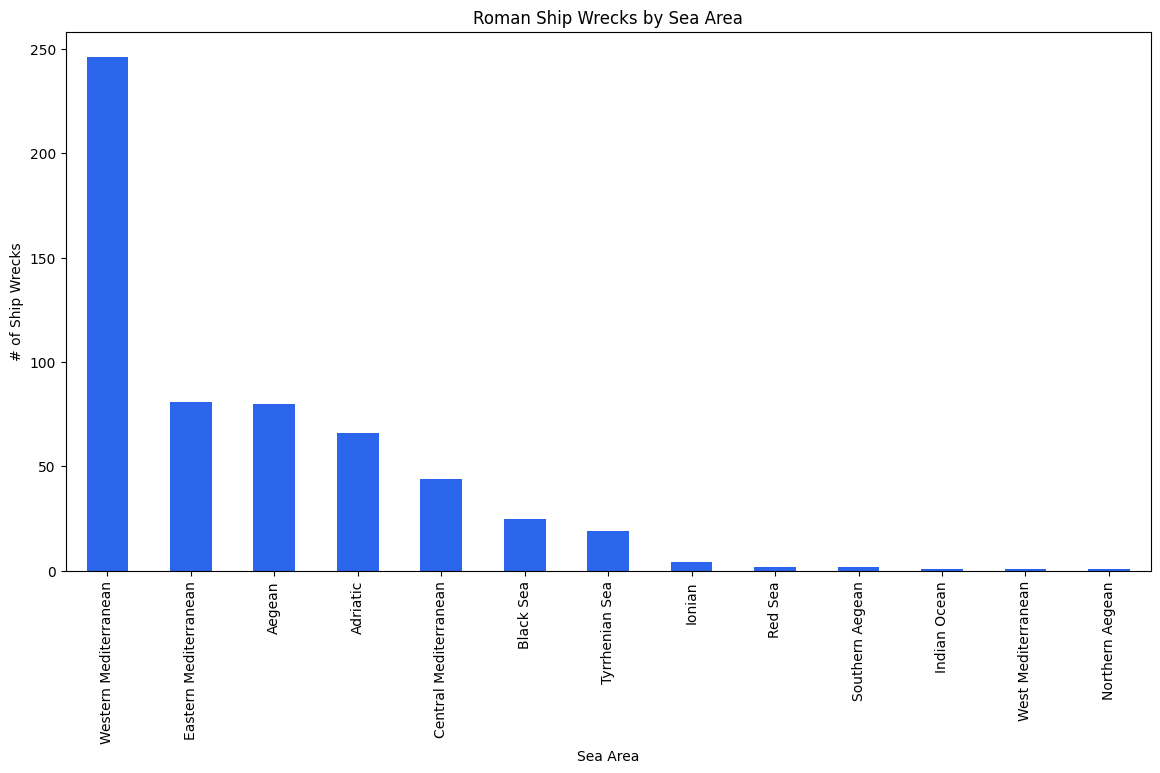

In [185]:
plt.figure(figsize=(14, 7))
df_seaareas["Sea area"].value_counts().plot(kind="bar", color="#2B65EC")
plt.title("Roman Ship Wrecks by Sea Area")
plt.xlabel("Sea Area")
plt.ylabel("# of Ship Wrecks")
plt.savefig("docs/images/shipwrecks_seaarea.png", bbox_inches="tight");

This is consistent with what we learned about traderoutes. Most of the ship wrecks were found close to Italy/Rome. This is also where we would expect most of the shipping traffic, bringing goods in and out of the capital of the center of Roman power. The other entries appear to scale downwards in relation to how far away the actual sea was from Italy/Rome, which suggests that perhaps it more a matter of less Roman ship travelling in these parts than any kind of increased danger.

Perhaps there is another pattern a weary would be Roman sailor can consider when deciding to sign-up for naval duty? Does the size of the ship matter?

## **RQ3:** How does estimated tonnage relate to the frequency of known Roman ship wrecks?

As before, we'll create a clean dataframe we can use to visualize tonnage.

In [186]:
def create_tonnage_dataframe(df_source):
    """
    Creates a clean dataframe for visualizing the estimated tonnage of Roman Ship Wrecks

    Args:
        df_source: the source dataframe.
    Returns:
        A cleaned dataframe with unwanted fields drops and missing data removed.
    """
    df_results = df_source.copy()
    df_results = df_results.drop(columns=["Latitude", "Longitude", "Sea area", "Place of origin", "Place of destination"])
    df_results.dropna(inplace=True)

    return df_results

In [187]:
df_tonnage = create_tonnage_dataframe(df_source=df_shipwrecks)
df_tonnage.head()

,Wreck ID,Name,Estimated tonnage
97,98,Andros (?),100.0
116,117,Porto Novo,138.0
140,141,Saintes-Maries-de-la-mer 18,50.0
148,149,Coscia di Donna,270.0
162,163,Marzamemi A,172.0


In [188]:
def plot_tonnage_chart(df_source):
    tonnage_data = df_source["Estimated tonnage"]
    
    min_tonnage = df["Estimated tonnage"].min()
    max_tonnage = df["Estimated tonnage"].max()
    bins = np.arange(min_tonnage, max_tonnage + 2, 25)

    
    plt.figure(figsize=(14, 7))
    tonnage_data.plot(kind='hist', color="#2B65EC", edgecolor='black', bins=bins)
    plt.xlabel("Tonnage")
    plt.ylabel("Frequency")
    plt.title("Roman Ship Wrecks by Tonnage")
    
    plt.savefig("docs/images/shipwrecks_tonnage.png", bbox_inches="tight");

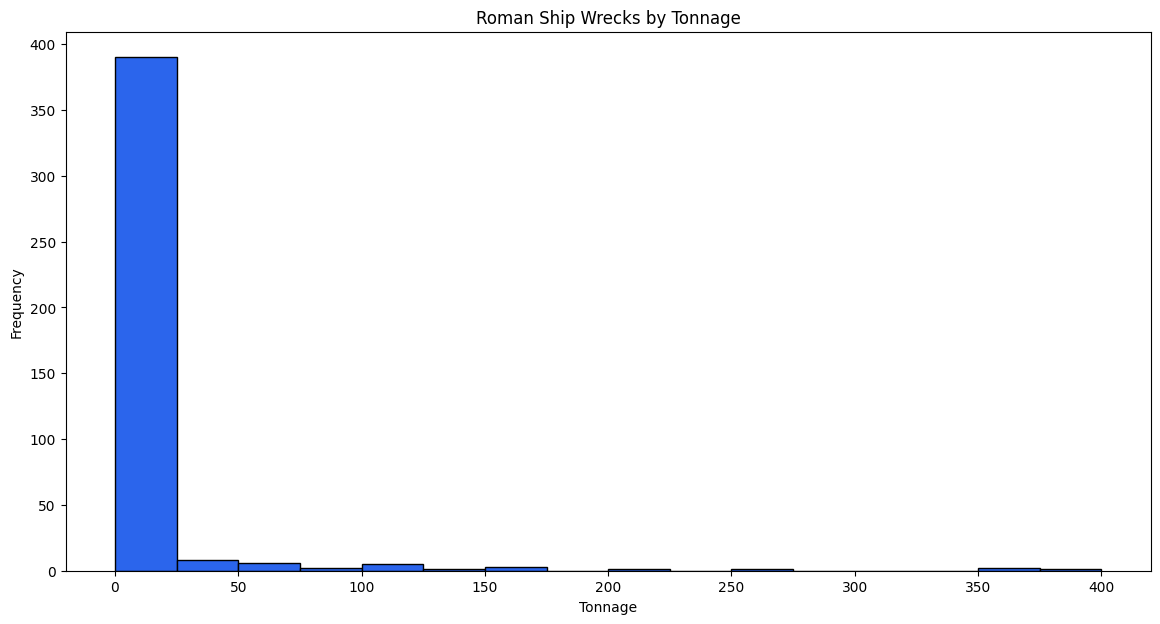

In [189]:
plot_tonnage_chart(df_tonnage)

The vast majority of the ship wrecks that were recorded in this dataset are 25 tonnes or less. We can take this to mean a few things - and without further data its difficult to disambiguate it. 

* Small Ships are more likely to ship wrecks. This isn't unreasonable. Smaller boats are less stable, and more liable to being damaged in a storm. They also more difficult to control under high winds. ( Having sailed modern sailing vessels of different sizes, this can be confirmed from personal experience)
* Most ships used for trade were under 25 tonnes. This could be true, but we would need to look outside this dataset to support the supposition.
* Both could be true. It could be the case that large ships were safer, but most ships were small.

So as a sailor, maybe we should give a sigh of relief when we find ourselves on a big heavy ship....

Of course, that could also depend on where its going...

## **RQ4:** Are there any hotspots in the lat/long data that appear to have a higher frequency of ship wrecks than the others?

As always, we start by creating a clean dataframe.

In [190]:
def create_latlong_dataframe(df_source):
    """
    Creates a clean dataframe for analyzing Lat / Long data from the Roman Ship Wreck database.
    This dataframe will be used for visualizing rough ship wreck locations as well as the relationship between location and tonnage.

    Args:
        df_source: The source dataframe.
    Results:
        returns a clean dataframe for Lat/Long data
    """
    df_results = df_source.copy()

    # Note: We'll keep estimated tonnage here as we'll want it for a second visualization.
    df_results = df_results.drop(columns=["Sea area", "Place of origin", "Place of destination"])
    df_results = df_results[df_results["Longitude"] > 5]
    df_results.dropna(inplace=True)
    return df_results

In [191]:
df_latlong = create_latlong_dataframe(df_source=df_shipwrecks)
df_latlong.head()

,Wreck ID,Name,Latitude,Longitude,Estimated tonnage
116,117,Porto Novo,41.50169,9.27490,138.0
148,149,Coscia di Donna,40.89190,8.21365,270.0
175,176,Margarina Point,44.48333,14.30000,30.0
209,210,Grado (Julia Felix),45.71666,13.33333,24.0
1014,8224,Plemmirio B,37.00001,15.32970,12.0


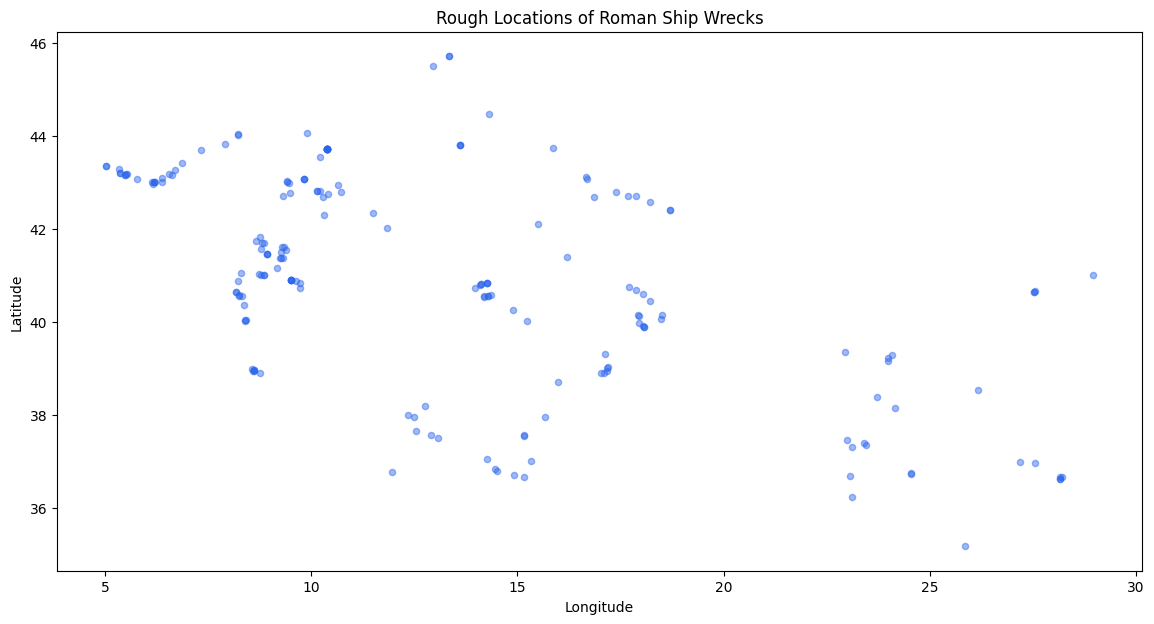

In [192]:
plt.figure(figsize=(14, 7))
plt.scatter(x=df_latlong["Longitude"], y=df_latlong["Latitude"], s=20, alpha=0.45, color="#2B65EC")
plt.title("Rough Locations of Roman Ship Wrecks")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("docs/images/shipwrecks_locations.png", bbox_inches="tight");

So it seems some places are scarier than others in the acient world. As we might've guessed, most of these locations are around Italy. Ther are a few clusters near the south of France which appears to be where most of the Ship Wrecks in the Eastern Mediterranean are concentrated. Ship Wrecks in the Western Mediterranean are more evenly distributed.


There is another question that we can ask of this data:

* We know low tonnage ships could be more likely to be ship wrecks.
* We know ships near Italy, the South of Franch etc could be more likely be ship wrecks

How does this map look when we visualize ship tonnage as well?

First we'll rescale the tonnage data to ease visualization.

In [193]:
new_min = 20
new_max = 200
old_min = df_latlong["Estimated tonnage"].min()
old_max = df_latlong["Estimated tonnage"].max()
df_latlong["Estimated tonnage"] = new_min + (df_latlong["Estimated tonnage"] - old_min) * (new_max - new_min) / (old_max - old_min)

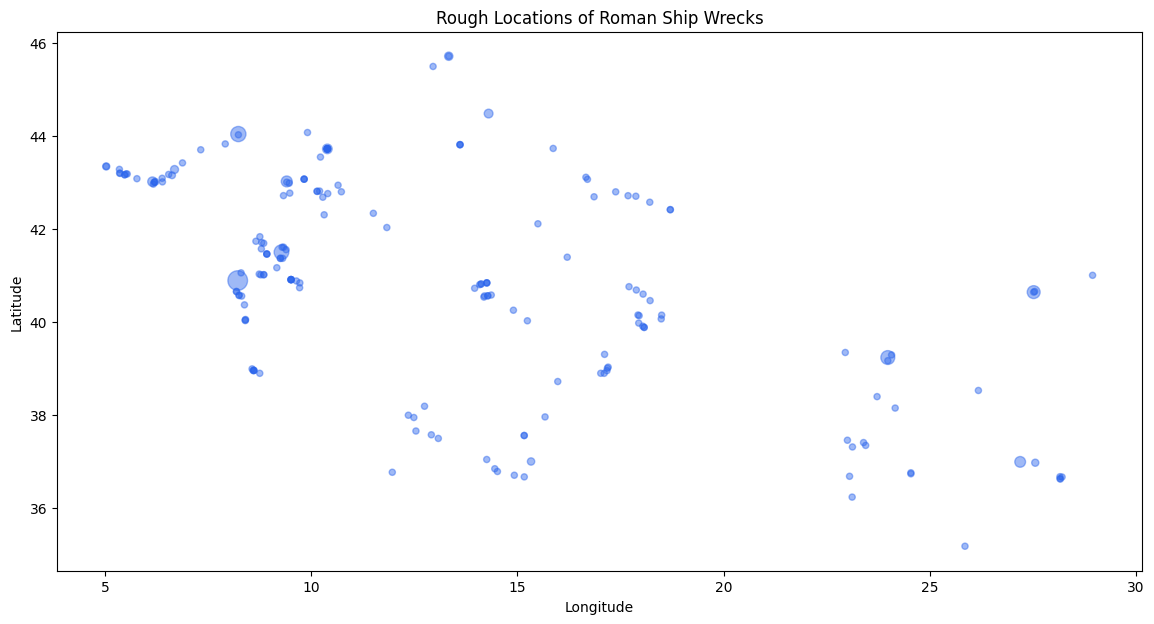

In [194]:
plt.figure(figsize=(14, 7))
plt.scatter(x=df_latlong["Longitude"], y=df_latlong["Latitude"], s=df_latlong["Estimated tonnage"], alpha=0.45, color="#2B65EC")
plt.title("Rough Locations of Roman Ship Wrecks")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("docs/images/shipwrecks_locations.png", bbox_inches="tight");

With tonnage taken into account, it seems that even in the more dangerous areas, recorded ship wrecks mostly involved smaller vessels. Now its possible that for some reason smaller vessels were just easier to find, or were preserved more easily - but given that smaller vessels would not only have fewer parts to preserve, but would also be more difficult to handle in a storm or other dangerous situation, it seems that a reasonable conclusion here:

If you're a Roman Sailor, size matters! Get on the biggest ship you can, or at least ask for some extra hazard pay!